对于具有if，else分支的递归结构而言，每一个分支都要有对应的return语句，一般来说在节点不为空的情况下return为节点自身。


### 💡 1. 检查树是否对称

> **解题思路**：核心在于处理以下 4 种边界与递归条件：

- 1️⃣ **两侧皆空**：无左节点也无右节点 $\rightarrow$ 返回 `True`
- 2️⃣ **单侧缺失**：只有左或只有右节点 $\rightarrow$ 返回 `False`
- 3️⃣ **数值冲突**：节点皆存在但 **值不相等** $\rightarrow$ 返回 `False`
- 4️⃣ **正常递推**：节点皆存在且 **值相等** $\rightarrow$ 继续向下递归

In [ ]:
# Definition for a binary tree node.
# class TreeNode(object):
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution(object):
    def isSymmetric(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: bool
        """
        if not root:
            return True

        def dfs(left,right):
            if not (left or right):#左树右树都不存在返回true
                return True
            if not (left and right):#左树右树只存在一个返回false
                return False
            if left.val!=right.val:#左右子树都存在但不对称返回false
                return False
            return dfs(left.left,right.right) and dfs(left.right,right.left)
        return dfs(root.left,root.right)

**#1.中序遍历的迭代做法**

核心思想:在中序遍历当中,根节点的左子树的最右边节点是根节点的前驱节点

中序遍历时,当在“拆桥”或者“无左子树”时才记录节点

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def inorderTraversal(self, root: Optional[TreeNode]) -> List[int]:
        res = []
        while root:
            if root.left:
                pre = root.left

                while pre.right and pre.right is not root:
                    pre = pre.right
                
                if pre.right is None:
                    pre.right = root
                    root = root.left
                    continue
                
                pre.right = None#能走到这一步说明左子树已经遍历完成.

            res.append(root.val)#没有左结点的情况下直接记录
            root = root.right

        return res

In [ ]:
#拓展:前序以及后序遍历的迭代方法

class Solution:

    def preorderTraversal(self, root: Optional[TreeNode]) -> List[int]:
        res = []
        while root:
            if root.left:
                pre = root.left
                while pre.right and pre.right is not root:
                    pre = pre.right

                # === 1. 未连则搭桥 ===
                if pre.right is None:
                    res.append(root.val)  # 【改动点 1】：搭桥时就记录！(根)
                    pre.right = root
                    root = root.left
                    continue

                # === 2. 已连则拆桥 ===
                pre.right = None
                # 【改动点 2】：拆桥时不再记录，直接往右走
                root = root.right

            else:
                # === 3. 无左子树 ===
                res.append(root.val)  # 没有左子树，也直接记录(根)
                root = root.right

        return res

    #后序遍历,技巧:将前序遍历的根->左->右改为根->右->左,最后再翻转结果列表即可
    class Solution:

    def postorderTraversal(self, root: Optional[TreeNode]) -> List[int]:
        res = []
        while root:
            # 原来的 left 全部变成 right
            if root.right:
                pre = root.right
                # 原来的 right 全部变成 left
                while pre.left and pre.left is not root:
                    pre = pre.left

                # 未连则搭桥
                if pre.left is None:
                    res.append(root.val)  # 搭桥时记录
                    pre.left = root
                    root = root.right  # 往右走
                    continue

                # 已连则拆桥
                pre.left = None
                root = root.left  # 往左走

            else:
                res.append(root.val)
                root = root.left

        # 【核心】：翻转结果列表 (根->右->左 变为 左->右->根)
        return res[::-1]

**#2.求树的最大直径**

In [1]:
class Solution(object):
    def diameterOfBinaryTree(self, root):
        self.diameter = 0

        def depth(node):
            if not node:
                return 0

            left = depth(node.left)      # 左子树高度,也是左子树的到根节点的最长路径
            right = depth(node.right)    # 右子树高度，也是右子树的到根节点的最长路径

            # 更新直径：左高度 + 右高度
            self.diameter = max(self.diameter, left + right)

            # 返回当前子树高度，返回值可以理解为当前树的高度，左子树与右子树高度可以理解为到根节点的高度
            return 1 + max(left, right)

        depth(root)
        return self.diameter

**#3.检查树的深度**

In [ ]:
class Solution(object):
    def maxDepth(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: int
        """
        if root:#采用递归的方法求最大深度
            left = self.maxDepth(root.left)
            right = self.maxDepth(root.right)
            return 1 + max(left, right)
        else:
            return 0

#4.树的翻转

In [ ]:
class Solution(object):
    def invertTree(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: Optional[TreeNode]
        """
        if not root:
            return None
        else:
            root.left = self.invertTree(root.right)
            root.right = self.invertTree(root.left)
            return root

**#5.树的层序遍历：树的层序遍历不需要提前知道树的深度**

注意：使用

            res = [[]*nums]
并不能生成一个含有nums个列表的二维列表，应该使用:

            res = [[] for _ in range(nums)]

In [ ]:
class Solution(object):#在生成含有列表的列表时，可以先生成小列表，然后将小列表加入到大列表中
    def levelOrder(self, root):
        if not root:
            return []
        else:
            queue = [root]
            res = []
            while queue:
                length = len(queue)
                current_list = [] # 每次循环创建新的列表对象
                for i in range(length):#对某一层的元素进行处理
                    node = queue.pop(0)
                    current_list.append(node.val)
                    if node.left:
                        queue.append(node.left)
                    if node.right:
                        queue.append(node.right)#添加的是对新列表的引用
                res.append(current_list)
            return res

**#6.从前序与中序构建二叉树**

方法一：

In [ ]:
class TreeNode(object):
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution(object):#这个方法从递归的角度入手，先获取先序遍历中根节点在中序遍历中的索引，然后根据索引确定根节点的左子树和右子树有多少节点，在递归调用构建左右子树
    def buildTree(self, preorder, inorder):
        if not preorder:
            return None
        else:
            index = inorder.index(preorder[0])
            root = TreeNode(preorder[0])          #拓展：从中序与后序构建二叉树，只需更改先序的索引即可
            root.left = self.buildTree(preorder[1:index+1],inorder[0:index]) #(preorder[0:index],inorder[0:index])
            root.right = self.buildTree(preorder[index+1:],inorder[index+1:])#preorder[index:-1],inorder[index+1:])
            return root

这个方法从递归的角度入手，先获取先序遍历中根节点在中序遍历中的索引，然后根据索引确定根节点的左子树和右子树有多少节点，在递归调用构建左右子树

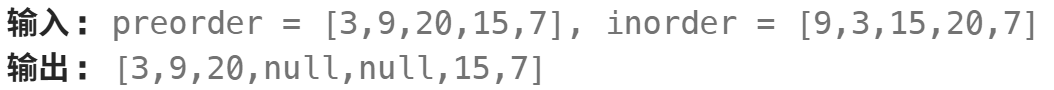

例如，对于这个例子而言，根节点3在中序中对应的位置为1，也就说明了左子树有一个节点，因此在后续的分配过程中，先序列表的值从第二个元素开始，将1个元素分给左子树，而对于中序遍历而言，只需将从第一个元素开始到根节点之前的元素返回即可。

方法二：

In [ ]:
class Solution(object):
    def buildTree(self, preorder, inorder):
        """
        :type preorder: List[int]
        :type inorder: List[int]
        :rtype: Optional[TreeNode]
        """
        def helper(root_index,left,right):#函数中的left与right反映的是左子树数组与右子树数组在中序列表中对应的索引，作用是用作递归的基本结束条件
            if left > right:              #root_index代表着根节点在先序列表中的索引
                return None
            else:
                root = TreeNode(preorder[root_index])
                i = inorder_dict[preorder[root_index]]#i代表着根节点在中序列表中的索引
                root.left = helper(root_index+1,left,i-1)
                root.right = helper(root_index+1+i-left,i+1,right)#i-left代表着一共有多少棵左子树，在第一棵左子树的位置移动左子树的距离，就到了右子树的根节点
                return root

        inorder_dict = {val:idx for idx,val in enumerate(inorder)}
        return helper(0,0,len(preorder)-1)

        利用前序与中序构建二叉树：
        root.left = helper(root_index+1,left,i-1)
        root.right = helper(root_index+1+i-left,i+1,right)
        右子树根节点位置=根节点位置+左子树个数+1

        利用后序与中序构建二叉树：
        root.left = helper(root_index - (right - i) - 1,left,i-1)
        root.right = helper(root_index - 1,i+1,right)
        左子树根节点位置 = 根节点位置 - 右子树个数 - 1

**#7.验证二叉搜索树**

**对于一棵有效二叉搜索树而言，中序遍历的结果是严格递增的**



In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def isValidBST(self, root: Optional[TreeNode]) -> bool:
        def check(root,l,r):
            if not root:
                return True
            if not (l < root.val < r):
                return False
            return check(root.left,l,root.val) and check(root.right,root.val,r)
        return check(root,-float('inf'),float('inf'))

**#8.将二叉树展开为列表**



In [ ]:
class Solution(object):
    def flatten(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: None Do not return anything, modify root in-place instead.
        """
        #此方法使用到栈的属性，先压右在压左保证先序遍历，使用的非递归先序遍历的方式还是很有意思的，这个要留意。
        if not root:
            return []
        else:
            stack = [root]
            prev = None
            while stack:
                node = stack.pop()#弹出的时候存在左节点会先弹左节点，
                if prev:#指的是当前节点的根节点
                    prev.right = node
                    prev.left = None
                prev = node
                if node.right:
                    stack.append(node.right)
                if node.left:
                    stack.append(node.left)
            return root

    while 栈非空:
        1. 弹出当前节点 = 栈.pop()
        2. 连接操作：if pre: pre.right = 当前节点; pre.left = None
        3. 入栈操作：先右后左（因为栈是后进先出）

**#9.二叉树的最近公共祖先**
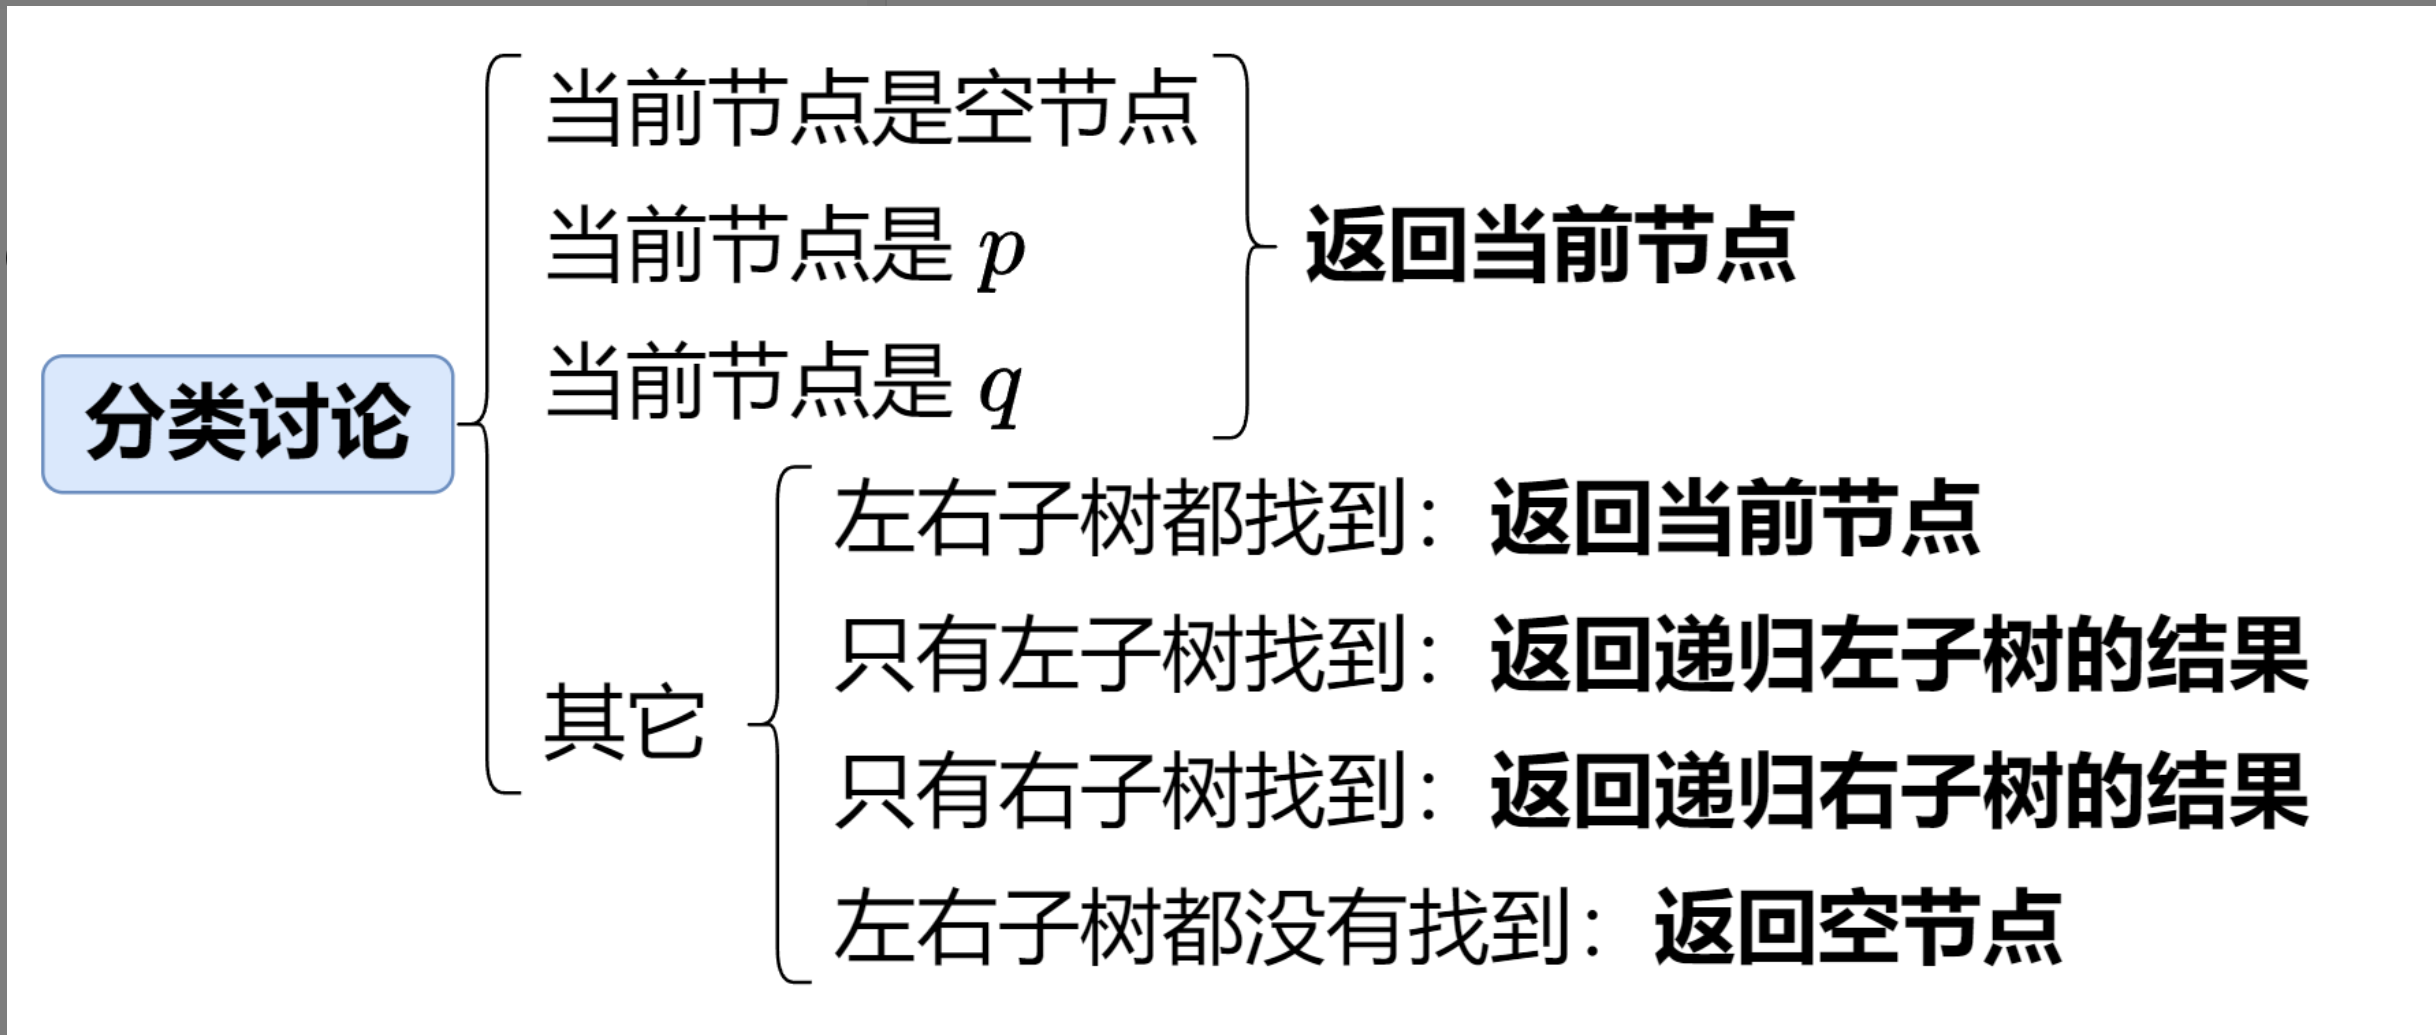

In [ ]:
class Solution(object):#该题的最大启发在于树中的递归值的返回，不需要修改树的结构，只需要返回左右子树是否包含节点的信息就可以了，如果有那就返回这个节点，如果没有不处理默认返回none。同时应该简化对节点的判断，将判断落在节点上，而非节点的左右节点。

    def lowestCommonAncestor(self, root: 'TreeNode', p: 'TreeNode', q: 'TreeNode') -> 'TreeNode':#从下往上判断,通过递归先走到最深处
        def dfs(node):
            if not node:
                return None
            if node == p or node ==q:#当前节点等于p或者q的时候，就没必要继续探索这个节点的左右子树了，因为如果遍历其他子树没有发现p或者q，说明p或者q位于这个节点的子树下面，此时公共祖先就是node
                return node

            left = dfs(node.left)
            right = dfs(node.right)

            if left and right:
                return node

            return left if left else right

        return dfs(root)

**#10.二叉搜索树的最近公共祖先:**
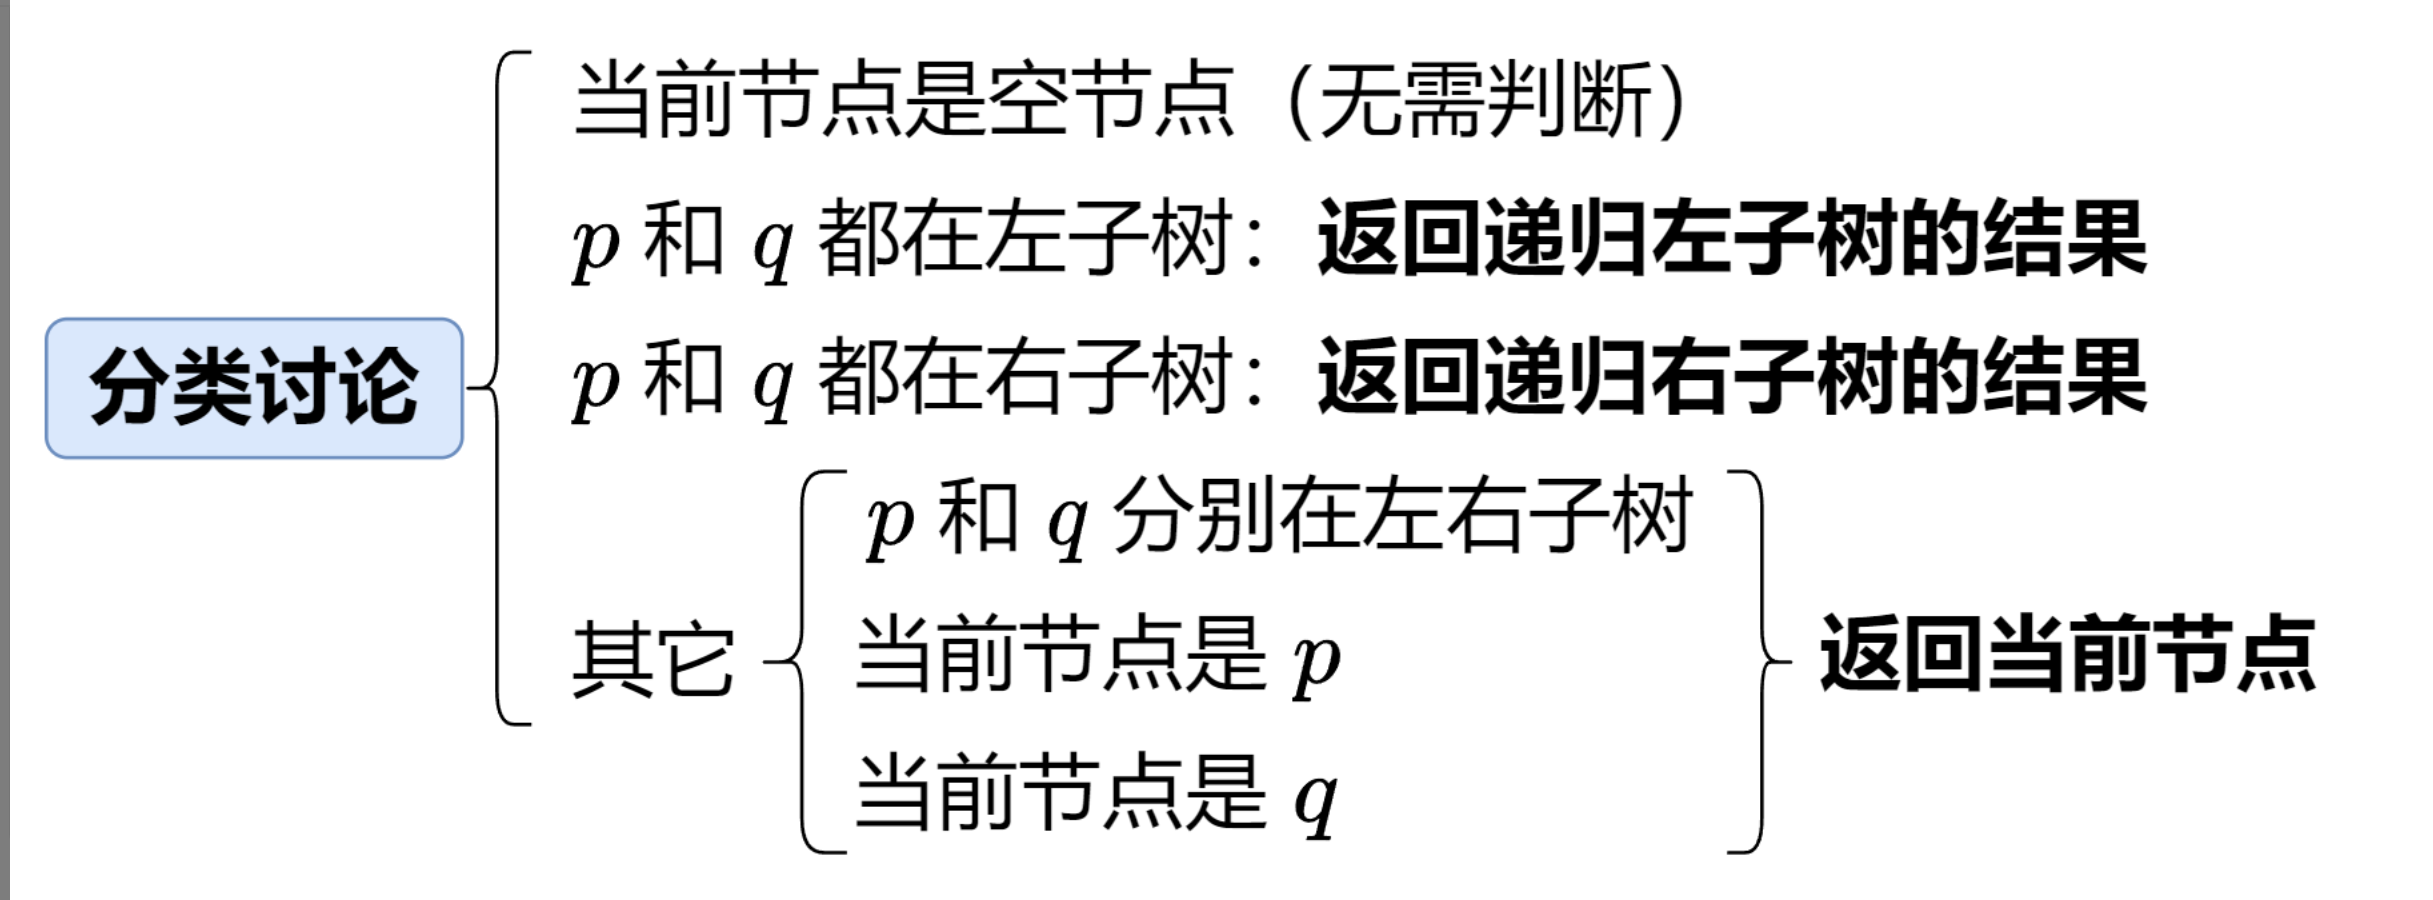
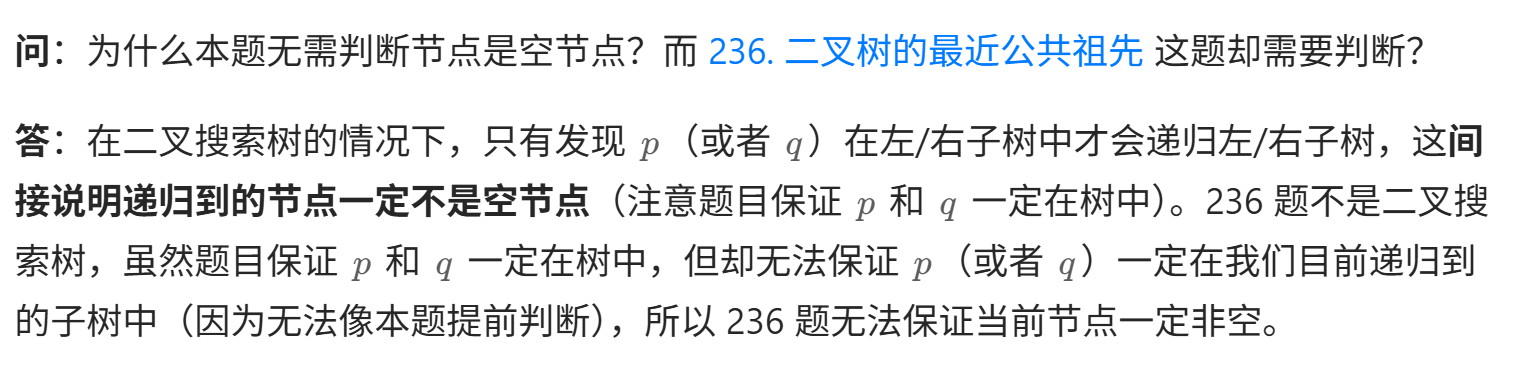

In [ ]:
class Solution:
    def lowestCommonAncestor(self, root: 'TreeNode', p: 'TreeNode', q: 'TreeNode') -> 'TreeNode':
        x = root.val
        if p.val < x and q.val < x:  # p 和 q 都在左子树
            return self.lowestCommonAncestor(root.left, p, q)
        if p.val > x and q.val > x:  # p 和 q 都在右子树
            return self.lowestCommonAncestor(root.right, p, q)
        return root  # 其它

**#11.最大路径和**

这个题有用到求连续n个数的最大和以及求树的最大直径的思路，采用递归方法在返回值时应该注意，不能将node.val+left+right返回，因为后续node会作为其他节点的子节点，所以最多只能返回当前节点与一个子节点的和，这个思路与求树的最大直径相似，因此我们要创建一个全局数组用来存放历史最大值，并将历史最大值与现在的和进行比较，看看是否需要更改。

**递归返回单边最大路径和 node.val+max(左,右,0)；遍历每一个节点，并以该节点作为路径的‘拐点’，来计算并更新全局的最大路径和。**


In [ ]:
# Definition for a binary tree node.
# class TreeNode(object):
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution(object):
    def maxPathSum(self, root):
        """
        :type root: Optional[TreeNode]
        :rtype: int
        """
        self.max_num = float('-inf')
        def check(root):
            if not root:
                return 0
            else:
                left = max(check(root.left),0)#对left以及right的处理是本题的关键
                right = max(check(root.right),0)#
                curr_sum = root.val+left+right
                self.max_num = max(self.max_num,curr_sum)
                return max(left,right)+root.val#但当前节点必须报告它能贡献的真实值，因此即使当root.val是负的也要返回，但为负值的情况下这个节点的父亲节点不会将其加入到路径中去
        check(root)
        return self.max_num

**#11.路径总和III**

采用前缀和的思想，最后在单次函数执行完之前，将当前之和删除，避免对其他分支造成影响。

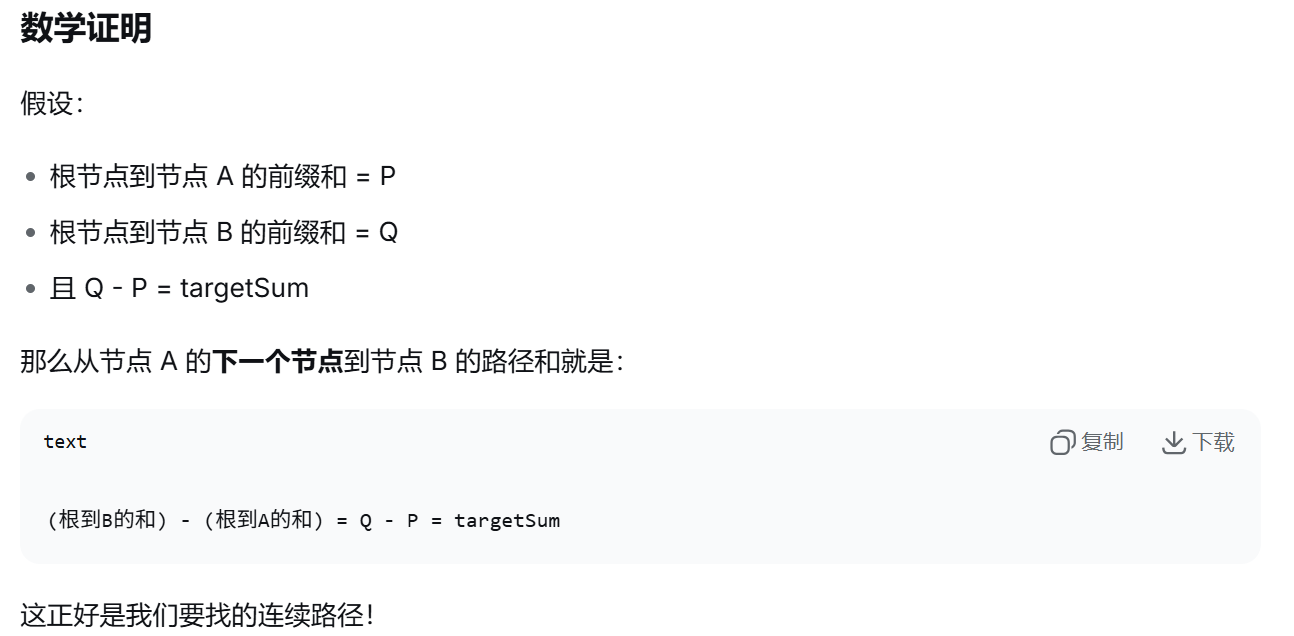
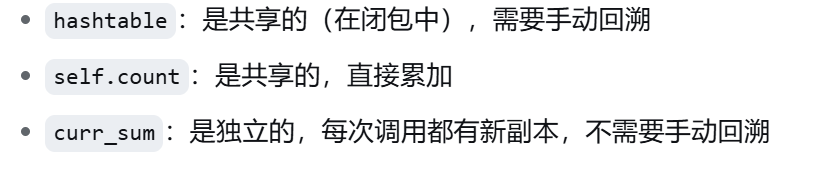

In [ ]:
class Solution:
    def pathSum(self, root: Optional[TreeNode], targetSum: int) -> int:
        # key：从根到 node 的节点值之和
        # value：节点值之和的出现次数
        # 注意在递归过程中，哈希表只保存根到 node 的路径的前缀的节点值之和
        cnt = defaultdict(int)  
        cnt[0] = 1 # 空路径的节点值之和为 0,存在从根节点开始就为 targetSum 的路径
        ans = 0

        # s 表示从根到 node 的父节点的节点值之和（node 的节点值尚未计入）
        def dfs(node: Optional[TreeNode], s: int) -> None:
            if node is None:
                return

            nonlocal ans
            s += node.val
            # 把 node 当作路径的终点，统计有多少个起点
            ans += cnt[s - targetSum] #先更新ans,在更新cnt,因为题目要求统计的是非空路径的个数,如果反过来,举一个最简单的例子,当target_sum=0的时候,如果根结点的值为1,
                                        #先更新cnt,那么cnt[1]=1,然后在执行ans += cnt[1-0],那么ans=1,但是实际上没有符合条件的路径,所以应该先更新ans,再更新cnt
            cnt[s] += 1
            dfs(node.left, s)
            dfs(node.right, s)
            cnt[s] -= 1  # 恢复现场（撤销 cnt[s] += 1）,因为此时遍历完了这个节点作为路径终点的所有路径,所以应该将这个节点的值从cnt中删除,以便于其他节点作为路径终点的时候不会受到这个节点的影响

        dfs(root, 0)
        return ans